# 1. Exploring FCMs Properties
- To gain a comprehensive understanding of the underlying structure and relationships within the Fuzzy Cognitive Maps (FCMs) derived from expert assessments on the World Cultural Heritage Site Systems (WCHS), we conducted a three-step analysis.
- Step 1: Data Import 
Import individual and group FCMs generated by expert participants.
Read data from CSV files and construct FCM connection matrices.
- STEP 2: Preliminary evaluation of structure, composition, and sum centrality of all FCMs.
The evaluation of FCMs structure involves calculation of the following measures:
- 2.1)  Counting nodes (concepts) and relationships (edges between concepts) and the sum centrality for each FCM.
- 2.2) Calculate the frequency of concepts and relationships across all FCMs.
- Step 3: Visualizing FCM Properties
Visualize the results of the preliminary evaluation to gain insights into the structure and composition of the FCMs.

## STEP 1:Import the generated individual FCMs of WCHS by expert participants.
- CSV files located in Original Data for each individual interview (EXP FCMx). The data should contain concepts and their interconnections as mentioned by the stakeholders.

In [1]:
import pandas as pd

# List of FCM files ( EXPFCM1.csv,EXPFCM2.csv,EXPFCM3.csv,EXPFCM4.csv,EXPFCM5.csv,EXPFCM6.csv,EXPFCM7.csv, EXPFCM8.csv)
fcm_files = [f'Original Data/EXPFCM{i}.csv' for i in range(1, 9)]

# Iterate over each FCM file
for fcm_file in fcm_files:
    # Read the FCM relationship matrix data from the CSV file
    df = pd.read_csv(fcm_file, index_col=0)  # Assuming the first column contains row labels

    # Print the relationship matrix for this FCM
    print(f"Matrix for {fcm_file}:")
    print(df)
    print("\n" + "="*50 + "\n")  # Separator between FCM matrices


Matrix for Original Data/EXPFCM1.csv:
      C1    C2   C3   C4   C5    C7    C8  C10  C11  C14  ...  C31  C36  C37  \
C1   0.0  0.00  0.0  0.0  0.0  0.00  0.00  0.0  0.0  0.0  ...  0.0  0.0  0.0   
C2   1.0  0.00  0.0  0.0  0.0  0.00  0.00  0.0  0.0  0.0  ...  0.0  0.0  0.0   
C3   1.0  0.00  0.0  0.0  0.0  0.00  0.00  0.0  0.0  0.0  ...  0.0  0.0  0.0   
C4   0.0  1.00  0.0  0.0  0.0  0.00  0.00  0.0  0.0  0.0  ...  0.0  0.0  0.0   
C5   0.0  0.00  0.0  0.0  0.0  0.00  0.00  0.0  0.0  0.0  ...  0.0  0.0  0.0   
C7   0.0  0.00  0.0  0.0  0.0  0.00  0.00  0.0  0.0  0.0  ...  0.0  0.0  0.0   
C8   0.0 -0.50  0.0  0.0  0.0  0.00  0.00  0.0  0.0  0.0  ...  0.0  0.0  0.0   
C10  0.0  0.00  0.0  0.0  0.0  0.00  0.50  0.0  0.0  0.0  ...  0.0  0.0  0.0   
C11  0.0  0.00  0.0  0.0  0.0  0.00  0.75  0.0  0.0  0.0  ...  0.0  0.0  0.0   
C14  0.0  0.00  0.0  0.0  0.0  0.00  0.25  0.0  0.0  0.0  ...  0.0  0.0  0.0   
C15  0.0 -1.00 -0.5  0.0  0.0  0.00  0.00  0.0  0.0  0.0  ...  0.0  0.0  0.0   
C1

### Results Interpretation step 1: 
The results will display the matrix for each FCM, with each matrix containing an equal number of columns and rows. If it is not, that indicates an error in the results.

## STEP 2: Preliminary evaluation of structure, composition, and sum centrality of all FCMs.
The evaluation of FCMs structure involves calculation of the following measures:
- 2.1)  Counting nodes (concepts) and relationships (edges between concepts)
- 2.2) calculating concept frequency across FCMs and calculating the frequency of relationships between pairs of concepts within FCMs

### 2.1 Counting nodes (concepts) and relationships (edges between concepts)
- A.Total Nodes (Concepts) (N): number of Concepts included in an FCM.
- B.Total Connections (Relationships, edges between concepts)(C): total number of Connections in either direction included in an FCM.
- C.Number of Driver Concepts: total number of Concepts with only out-degree.
- D.Number of Receiver Concepts: total number of concepts with only in-degree
- E.Number of Ordinary Concepts: number of Concepts with both in-degree and out-degree
- F.Calculate Centrality (C) for each concept: Sum the in-degree and out-degree of the concept.
- G.Calculate Centrality Degree (ci): calculated ci as the weighted contribution of each concept i, where n is the number of connections a concept has and a is the weight of each connection. We refer to this value as absolute degree centrality. 
- H.Sum centrality (SC) for each FCM. which is a measure of the absolute degree centrality of all concepts in an FCM. (add the equation).

In [2]:
from collections import Counter
import pandas as pd

# List of FCM files ( EXPFCM1.csv,EXPFCM2.csv,EXPFCM3.csv,EXPFCM4.csv,EXPFCM5.csv,EXPFCM6.csv,EXPFCM7.csv, EXPFCM8.csv)
fcm_files = [f'Original Data/EXPFCM{i}.csv' for i in range(1, 9)]

# Iterate over each FCM file
for fcm_file in fcm_files:
    # Read the FCM relationship matrix data from the CSV file
    df = pd.read_csv(fcm_file, index_col=0)  # Assuming the first column contains row labels

    # Total number of concepts
    total_concepts = len(df.index)

    # Total number of connections (considering any non-zero value as a connection)
    total_connections = (df != 0).sum().sum()

    # Indegree and Outdegree of each concept (considering any non-zero value as a connection)
    indegrees = (df != 0).sum(axis=0)
    outdegrees = (df != 0).sum(axis=1)

    # Centrality: the summation of its outdegree and indegree scores (binary, ignoring the relationship value)
    centrality = outdegrees + indegrees

    # Degree: the summation of the absolute values of the outdegree and indegree scores (absolute centrality)
    degree = df.abs().sum(axis=0) + df.abs().sum(axis=1)

    # Type of concept (driver, ordinary, receiver)
    types = []
    for i in range(total_concepts):
        if indegrees.iloc[i] == 0:
            types.append("Driver")
        elif outdegrees.iloc[i] == 0:
            types.append("Receiver")
        else:
            types.append("Ordinary")

    # Creating a DataFrame to store the results
    results_df = pd.DataFrame({
        'Indegree': indegrees,
        'Outdegree': outdegrees,
        'Centrality': centrality,
        'Degree': degree,  # Degree is the absolute value of the sum of in/out degrees
        'Type': types
    })

    # Counting the number of Driver, Receiver, and Ordinary concepts
    type_counts = Counter(types)

    # Print results for this FCM
    print(f"Results for {fcm_file}:")
    print("Number of Concepts:", total_concepts)
    print("Total Number of Connections:", total_connections)
    print("Number of Driver Concepts:", type_counts['Driver'])
    print("Number of Receiver Concepts:", type_counts['Receiver'])
    print("Number of Ordinary Concepts:", type_counts['Ordinary'])

    # Print the DataFrame
    print(results_df)

    # Sum the degree values to get Sc (the total degree/absolute centrality for all components in the FCM)
    Sc = results_df['Degree'].sum()

    # Print the total centrality for this FCM
    print(f"Total Degree Centrality (Sc) for {fcm_file}: {Sc}")
    print("\n" + "="*50 + "\n")  # Separator between FCM results


Results for Original Data/EXPFCM1.csv:
Number of Concepts: 30
Total Number of Connections: 50
Number of Driver Concepts: 13
Number of Receiver Concepts: 1
Number of Ordinary Concepts: 16
     Indegree  Outdegree  Centrality  Degree      Type
C1          5          2           7    7.00  Ordinary
C2          6          1           7    4.75  Ordinary
C3          2          1           3    2.00  Ordinary
C4          0          1           1    1.00    Driver
C5          0          2           2    1.25    Driver
C7          2          0           2    1.75  Receiver
C8          5          1           6    3.00  Ordinary
C10         0          1           1    0.50    Driver
C11         0          2           2    1.25    Driver
C14         0          1           1    0.25    Driver
C15         1          3           4    2.50  Ordinary
C19         0          2           2    1.25    Driver
C20         2          1           3    1.75  Ordinary
C21         7          1           8    7.7

### Results Interpretation step 2.1: 
- The outputs consist of various metrics that elucidate the structure and influence of concepts within each specific FCM.
For instance, in EXPFCM1, C1 is identified as a driver concept, whereas in EXPFCM2, the same concept is presented as a receiver concept. This illustrates the distinctions between FCMs and the role of each concept based on expert perspectives and professionalism. 
-It also demonstrates how the quantity of concepts within each FCM and the number of relationships influence the standard centrality of each FCM.

## 2.2 Calculate the frequency of concepts and relationships across all FCMs.
Here we are importing all FCMs together to examine the frequency of concepts and the frequency of relationships between pairs of concepts across all FCMs.

In [3]:
import os
from collections import Counter
import pandas as pd

# File paths for FCM CSV files
file_paths = [f'Original Data/EXPFCM{i}.csv' for i in range(1, 9)]

# Dictionary to store the frequency of each concept
concept_frequency = {}

# Set to store unique concepts
unique_concepts = set()

# List to store all relationships from all FCMs
all_relationships = []

# Load each FCM, extract unique concepts and relationships
for file_path in file_paths:
    # Load the FCM relationship matrix
    df = pd.read_csv(file_path, index_col=0)

    # Count concept frequency across FCMs
    for concept in df.columns:
        concept_frequency[concept] = concept_frequency.get(concept, 0) + 1

    # Add unique concepts (from both index and columns)
    unique_concepts.update(df.index)
    unique_concepts.update(df.columns)

    # Extract relationships (non-zero values)
    all_relationships.extend([(row, col) for row in df.index for col in df.columns 
                              if not pd.isna(df.at[row, col]) and df.at[row, col] != 0])

# Calculate the total number of unique concepts
total_unique_concepts = len(unique_concepts)

# Calculate the total number of existing relationships
total_existing_relationships = len(all_relationships)

# Sort concept frequency by values (ascending order)
concept_frequency_sorted = sorted(concept_frequency.items(), key=lambda x: x[1])

# Create a Counter to count the frequency of each relationship
relationship_counter = Counter(all_relationships)

# Create a DataFrame to store the frequency of relationships
frequency_df = pd.DataFrame({'Relationship': list(relationship_counter.keys()), 
                             'Frequency': list(relationship_counter.values())})

# Sort the relationship frequency DataFrame by frequency in descending order
frequency_df = frequency_df.sort_values(by='Frequency', ascending=False)

# Reset index for better display
frequency_df.reset_index(drop=True, inplace=True)

# Ensure the output directory exists
output_dir = 'Analysis and output folders'
os.makedirs(output_dir, exist_ok=True)

# Save concept frequency as a CSV file
output_concept_file = os.path.join(output_dir, 'concept_frequency_across_fcms.csv')
df_concept_frequency = pd.DataFrame(concept_frequency_sorted, columns=['Concept', 'Frequency'])
df_concept_frequency.to_csv(output_concept_file, index=False)

# Save relationship frequency as a CSV file
output_relationship_file = os.path.join(output_dir, 'Relationship_frequency_across_fcms.csv')
frequency_df.to_csv(output_relationship_file, index=False)

# Print the results
print("Concept frequency across all FCMs:")
for concept, freq in concept_frequency_sorted:
    print(f"Concept '{concept}' mentioned {freq} times across all FCMs")

print("\nRelationship frequency (excluding 0 values):")
print(frequency_df)

# Print total number of unique concepts and relationships
print(f"\nTotal number of unique concepts across all FCMs: {total_unique_concepts}")
print(f"Total number of existing relationships across all FCMs: {total_existing_relationships}")


Concept frequency across all FCMs:
Concept 'C19' mentioned 1 times across all FCMs
Concept 'C34' mentioned 1 times across all FCMs
Concept 'C12' mentioned 1 times across all FCMs
Concept 'C32' mentioned 1 times across all FCMs
Concept 'C39' mentioned 1 times across all FCMs
Concept 'C5' mentioned 2 times across all FCMs
Concept 'C10' mentioned 2 times across all FCMs
Concept 'C20' mentioned 2 times across all FCMs
Concept 'C44' mentioned 2 times across all FCMs
Concept 'C45' mentioned 2 times across all FCMs
Concept 'C48' mentioned 2 times across all FCMs
Concept 'C33' mentioned 2 times across all FCMs
Concept 'C17' mentioned 2 times across all FCMs
Concept 'C16' mentioned 2 times across all FCMs
Concept 'C31' mentioned 3 times across all FCMs
Concept 'C30' mentioned 3 times across all FCMs
Concept 'C6' mentioned 3 times across all FCMs
Concept 'C9' mentioned 3 times across all FCMs
Concept 'C35' mentioned 3 times across all FCMs
Concept 'C49' mentioned 3 times across all FCMs
Concept 

### Results Interpretation step 2.2: 
- It displays the aggregate count of relationships among all FCMs and the quantity of distinct concepts. It also indicates the frequency of concepts and relationships in the fcms CSV file, as well as the frequency of relationships within the same file.

## STEP 3: Visualization of exploring Properties of FCMs
Here we will construct a network to illustrate the results, comprising nodes that symbolize concepts and edges (arrows) that indicate their relationships. The dimensions of the nodes in the network are determined by their degree (number of connections) to emphasize more central concepts, while the width and color of edges fluctuate based on their frequency, ensuring a consistent color for improved contrast.

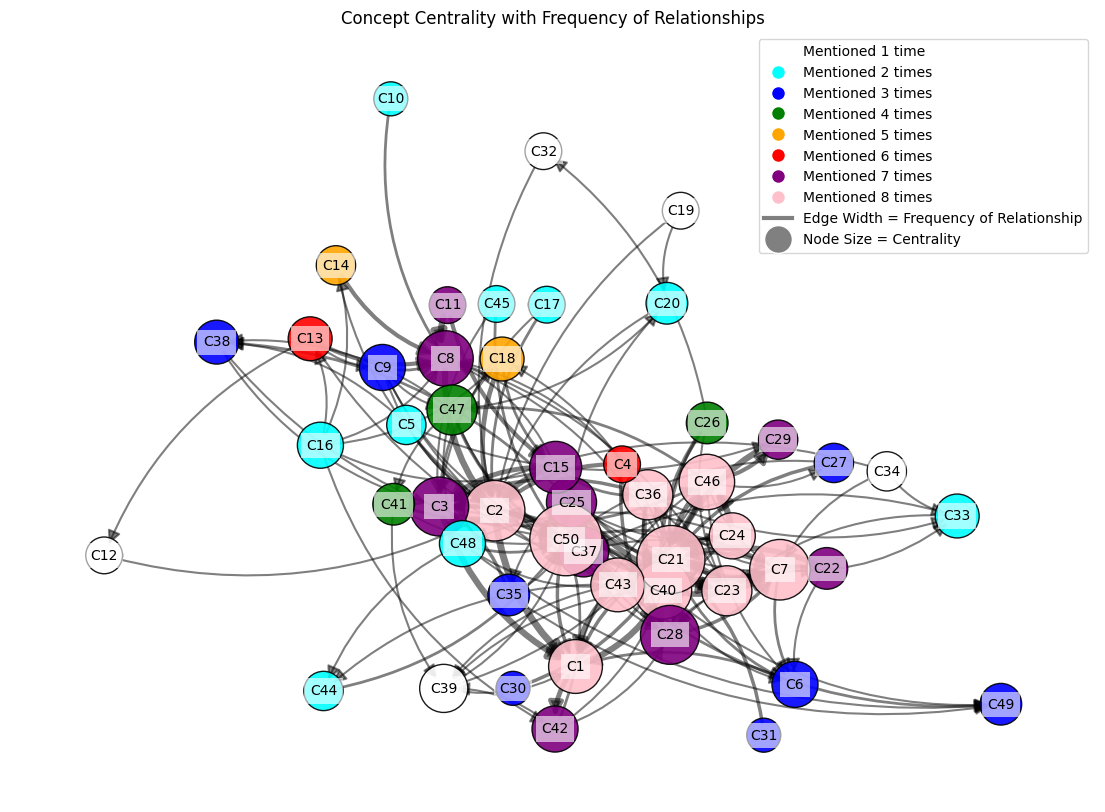

In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from ast import literal_eval

# Read the concept frequency data
df_concept_frequency = pd.read_csv("Analysis and output folders/concept_frequency_across_fcms.csv")

# Define the order of concepts
concept_order = [f"C{i}" for i in range(1, 51)]

# File paths for FCM CSV files
file_paths = [f'Original Data/EXPFCM{i}.csv' for i in range(1, 9)]

# Read each CSV file into a separate DataFrame
dfs = [pd.read_csv(file_path, index_col=0) for file_path in file_paths]

# Create a dictionary to store the color for each FCM
fcm_colors = {f'FCM{i+1}': color for i, color in enumerate(['pink', 'yellow', 'cyan', 'grey', 'blue', 'green', 'orange', 'purple'])}

# Create a dictionary to store the concept colors
concept_colors = {}

# Define colors for mentions
mention_colors = [
    'white',  # Mentioned 1 time
    'cyan',   # Mentioned 2 times
    'blue',   # Mentioned 3 times
    'green',  # Mentioned 4 times
    'orange', # Mentioned 5 times
    'red',    # Mentioned 6 times
    'purple', # Mentioned 7 times
    'pink'    # Mentioned 8 times
]

# Iterate over the concepts and assign colors based on the number of FCMs
for concept in df_concept_frequency['Concept']:
    count = sum(concept in df.columns for df in dfs)
    
    if 1 <= count <= 8:
        concept_colors[concept] = mention_colors[count - 1]  # Adjust index for colors
    else:
        concept_colors[concept] = 'gray'  # Default color if mentioned more than 8 times

# Create a directed graph
G = nx.DiGraph()

# Load frequency data
frequency_df = pd.read_csv("Analysis and output folders/Relationship_frequency_across_fcms.csv")  # Adjust path if necessary

# Convert 'Relationship' column from string to tuple if necessary
frequency_df['Relationship'] = frequency_df['Relationship'].apply(literal_eval)

# Add edges from the DataFrame with varying widths based on frequency
for index, row in frequency_df.iterrows():
    source, target = row['Relationship']
    weight = row['Frequency']
    G.add_edge(source, target, weight=weight)

# Set positions for the nodes using a layout algorithm
pos = nx.spring_layout(G, k=0.5, seed=42)  # Adjust k and seed for better layout

# Draw the graph with enhancements
plt.figure(figsize=(14, 10))

# Draw nodes
node_sizes = [500 + 100 * G.degree(node) for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=[concept_colors.get(node, 'gray') for node in G.nodes()],
                       node_size=node_sizes, alpha=0.9, edgecolors='black')

# Draw edges with arrows and curvature
edge_widths = [d['weight'] * 0.5 + 1 for u, v, d in G.edges(data=True)]  # Increased width for visibility
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5, edge_color='black', 
                         arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.2')  # Added curvature

# Remove the edge labels
# edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=8)

# Draw labels for nodes
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Show legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 1 time', markerfacecolor='white', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 2 times', markerfacecolor='cyan', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 3 times', markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 4 times', markerfacecolor='green', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 5 times', markerfacecolor='orange', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 6 times', markerfacecolor='red', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 7 times', markerfacecolor='purple', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 8 times', markerfacecolor='pink', markersize=10),
    plt.Line2D([0], [0], color='black', lw=3, label='Edge Width = Frequency of Relationship', alpha=0.5),
    plt.Line2D([0], [0], marker='o', color='w', label='Node Size = Centrality', markerfacecolor='gray', markersize=20),
]

# Add a legend for node size and edge width
plt.legend(handles=legend_elements, loc='best', title='')

plt.title("Concept Centrality with Frequency of Relationships")
plt.axis('off')  # Turn off the axis
plt.show()


### Here, we will utilize the concept labels in the network instead of the concept IDs by extracting the labels from the Concept Labels CSV located in the original data folder.

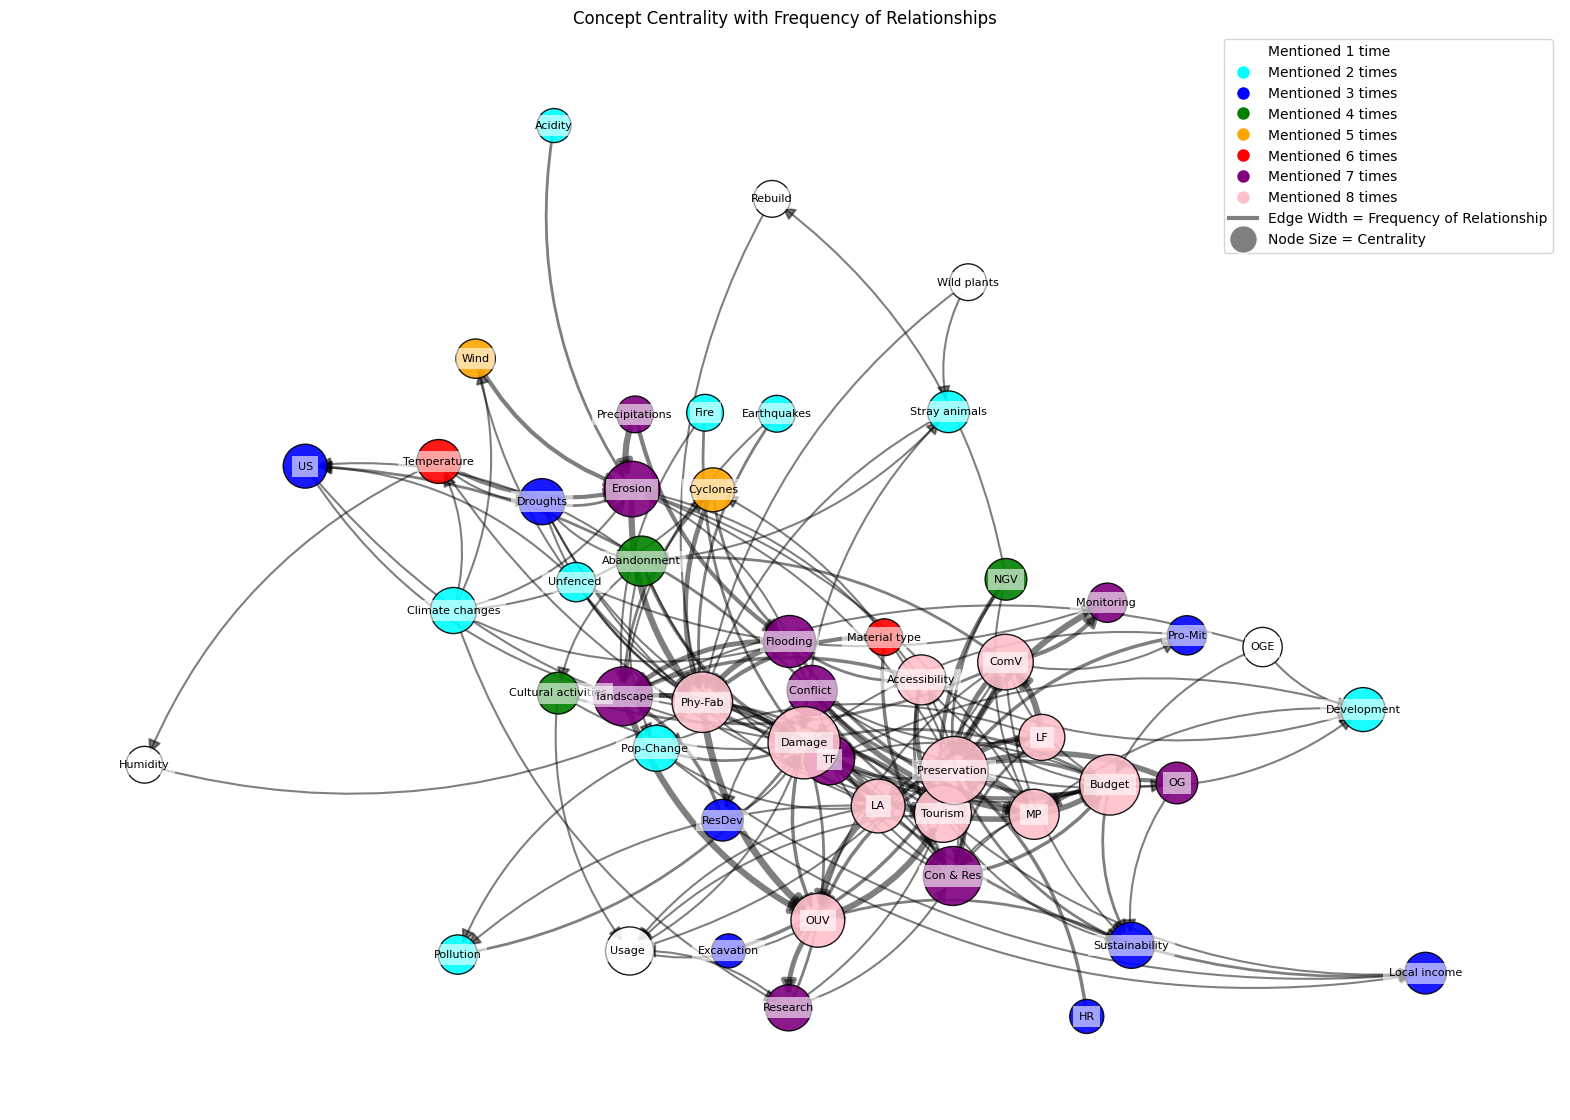

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from ast import literal_eval

# Read the concept frequency data
df_concept_frequency = pd.read_csv("Analysis and output folders/concept_frequency_across_fcms.csv")

# Read the concept ID to label mapping
concept_labels_df = pd.read_csv("Original Data/Concept labels.csv")  # Adjust the file name as necessary
concept_labels = dict(zip(concept_labels_df['Concept ID'], concept_labels_df['Label']))


# Define the order of concepts
concept_order = [f"C{i}" for i in range(1, 51)]

# File paths for FCM CSV files
file_paths = [f'Original Data/EXPFCM{i}.csv' for i in range(1, 9)]

# Read each CSV file into a separate DataFrame
dfs = [pd.read_csv(file_path, index_col=0) for file_path in file_paths]

# Create a dictionary to store the color for each FCM
fcm_colors = {f'FCM{i+1}': color for i, color in enumerate(['pink', 'yellow', 'cyan', 'grey', 'blue', 'green', 'orange', 'purple'])}

# Create a dictionary to store the concept colors
concept_colors = {}

# Define colors for mentions
mention_colors = [
    'white',  # Mentioned 1 time
    'cyan',   # Mentioned 2 times
    'blue',   # Mentioned 3 times
    'green',  # Mentioned 4 times
    'orange', # Mentioned 5 times
    'red',    # Mentioned 6 times
    'purple', # Mentioned 7 times
    'pink'    # Mentioned 8 times
]

# Iterate over the concepts and assign colors based on the number of FCMs
for concept in df_concept_frequency['Concept']:
    count = sum(concept in df.columns for df in dfs)
    
    if 1 <= count <= 8:
        concept_colors[concept] = mention_colors[count - 1]  # Adjust index for colors
    else:
        concept_colors[concept] = 'gray'  # Default color if mentioned more than 8 times

# Create a directed graph
G = nx.DiGraph()

# Load frequency data
frequency_df = pd.read_csv("Analysis and output folders/Relationship_frequency_across_fcms.csv")  # Adjust path if necessary

# Convert 'Relationship' column from string to tuple if necessary
frequency_df['Relationship'] = frequency_df['Relationship'].apply(literal_eval)

# Add edges from the DataFrame with varying widths based on frequency
for index, row in frequency_df.iterrows():
    source, target = row['Relationship']
    weight = row['Frequency']
    G.add_edge(source, target, weight=weight)

# Set positions for the nodes using a layout algorithm
pos = nx.spring_layout(G, k=0.5, seed=42)  # Adjust k and seed for better layout

# Draw the graph with enhancements
plt.figure(figsize=(20, 14))  # Increased figure size

# Draw nodes
node_sizes = [500 + 100 * G.degree(node) for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=[concept_colors.get(node, 'gray') for node in G.nodes()],
                       node_size=node_sizes, alpha=0.9, edgecolors='black')

# Draw edges with arrows and curvature
edge_widths = [d['weight'] * 0.5 + 1 for u, v, d in G.edges(data=True)]  # Increased width for visibility
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5, edge_color='black', 
                         arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.2')  # Added curvature

# Draw labels for nodes using the concept labels
nx.draw_networkx_labels(G, pos, labels=concept_labels, font_size=8, font_family='sans-serif', 
                         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Show legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 1 time', markerfacecolor='white', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 2 times', markerfacecolor='cyan', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 3 times', markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 4 times', markerfacecolor='green', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 5 times', markerfacecolor='orange', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 6 times', markerfacecolor='red', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 7 times', markerfacecolor='purple', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 8 times', markerfacecolor='pink', markersize=10),
    plt.Line2D([0], [0], color='black', lw=3, label='Edge Width = Frequency of Relationship', alpha=0.5),
    plt.Line2D([0], [0], marker='o', color='w', label='Node Size = Centrality', markerfacecolor='gray', markersize=20),
]

# Add a legend for node size and edge width
plt.legend(handles=legend_elements, loc='best', title='')

# Save the figure as an image
plt.savefig("concept_centrality_fcm_graph.png", format='PNG', dpi=300, bbox_inches='tight')

plt.title("Concept Centrality with Frequency of Relationships")
plt.axis('off')  # Turn off the axis
plt.show()





### Results Interpretation step 3: 
- The network map illustrates the predominant concepts referenced by stakeholders, while the strength of relationships between pairs of concepts signifies the agreement and validation of stakeholders regarding these relationships.

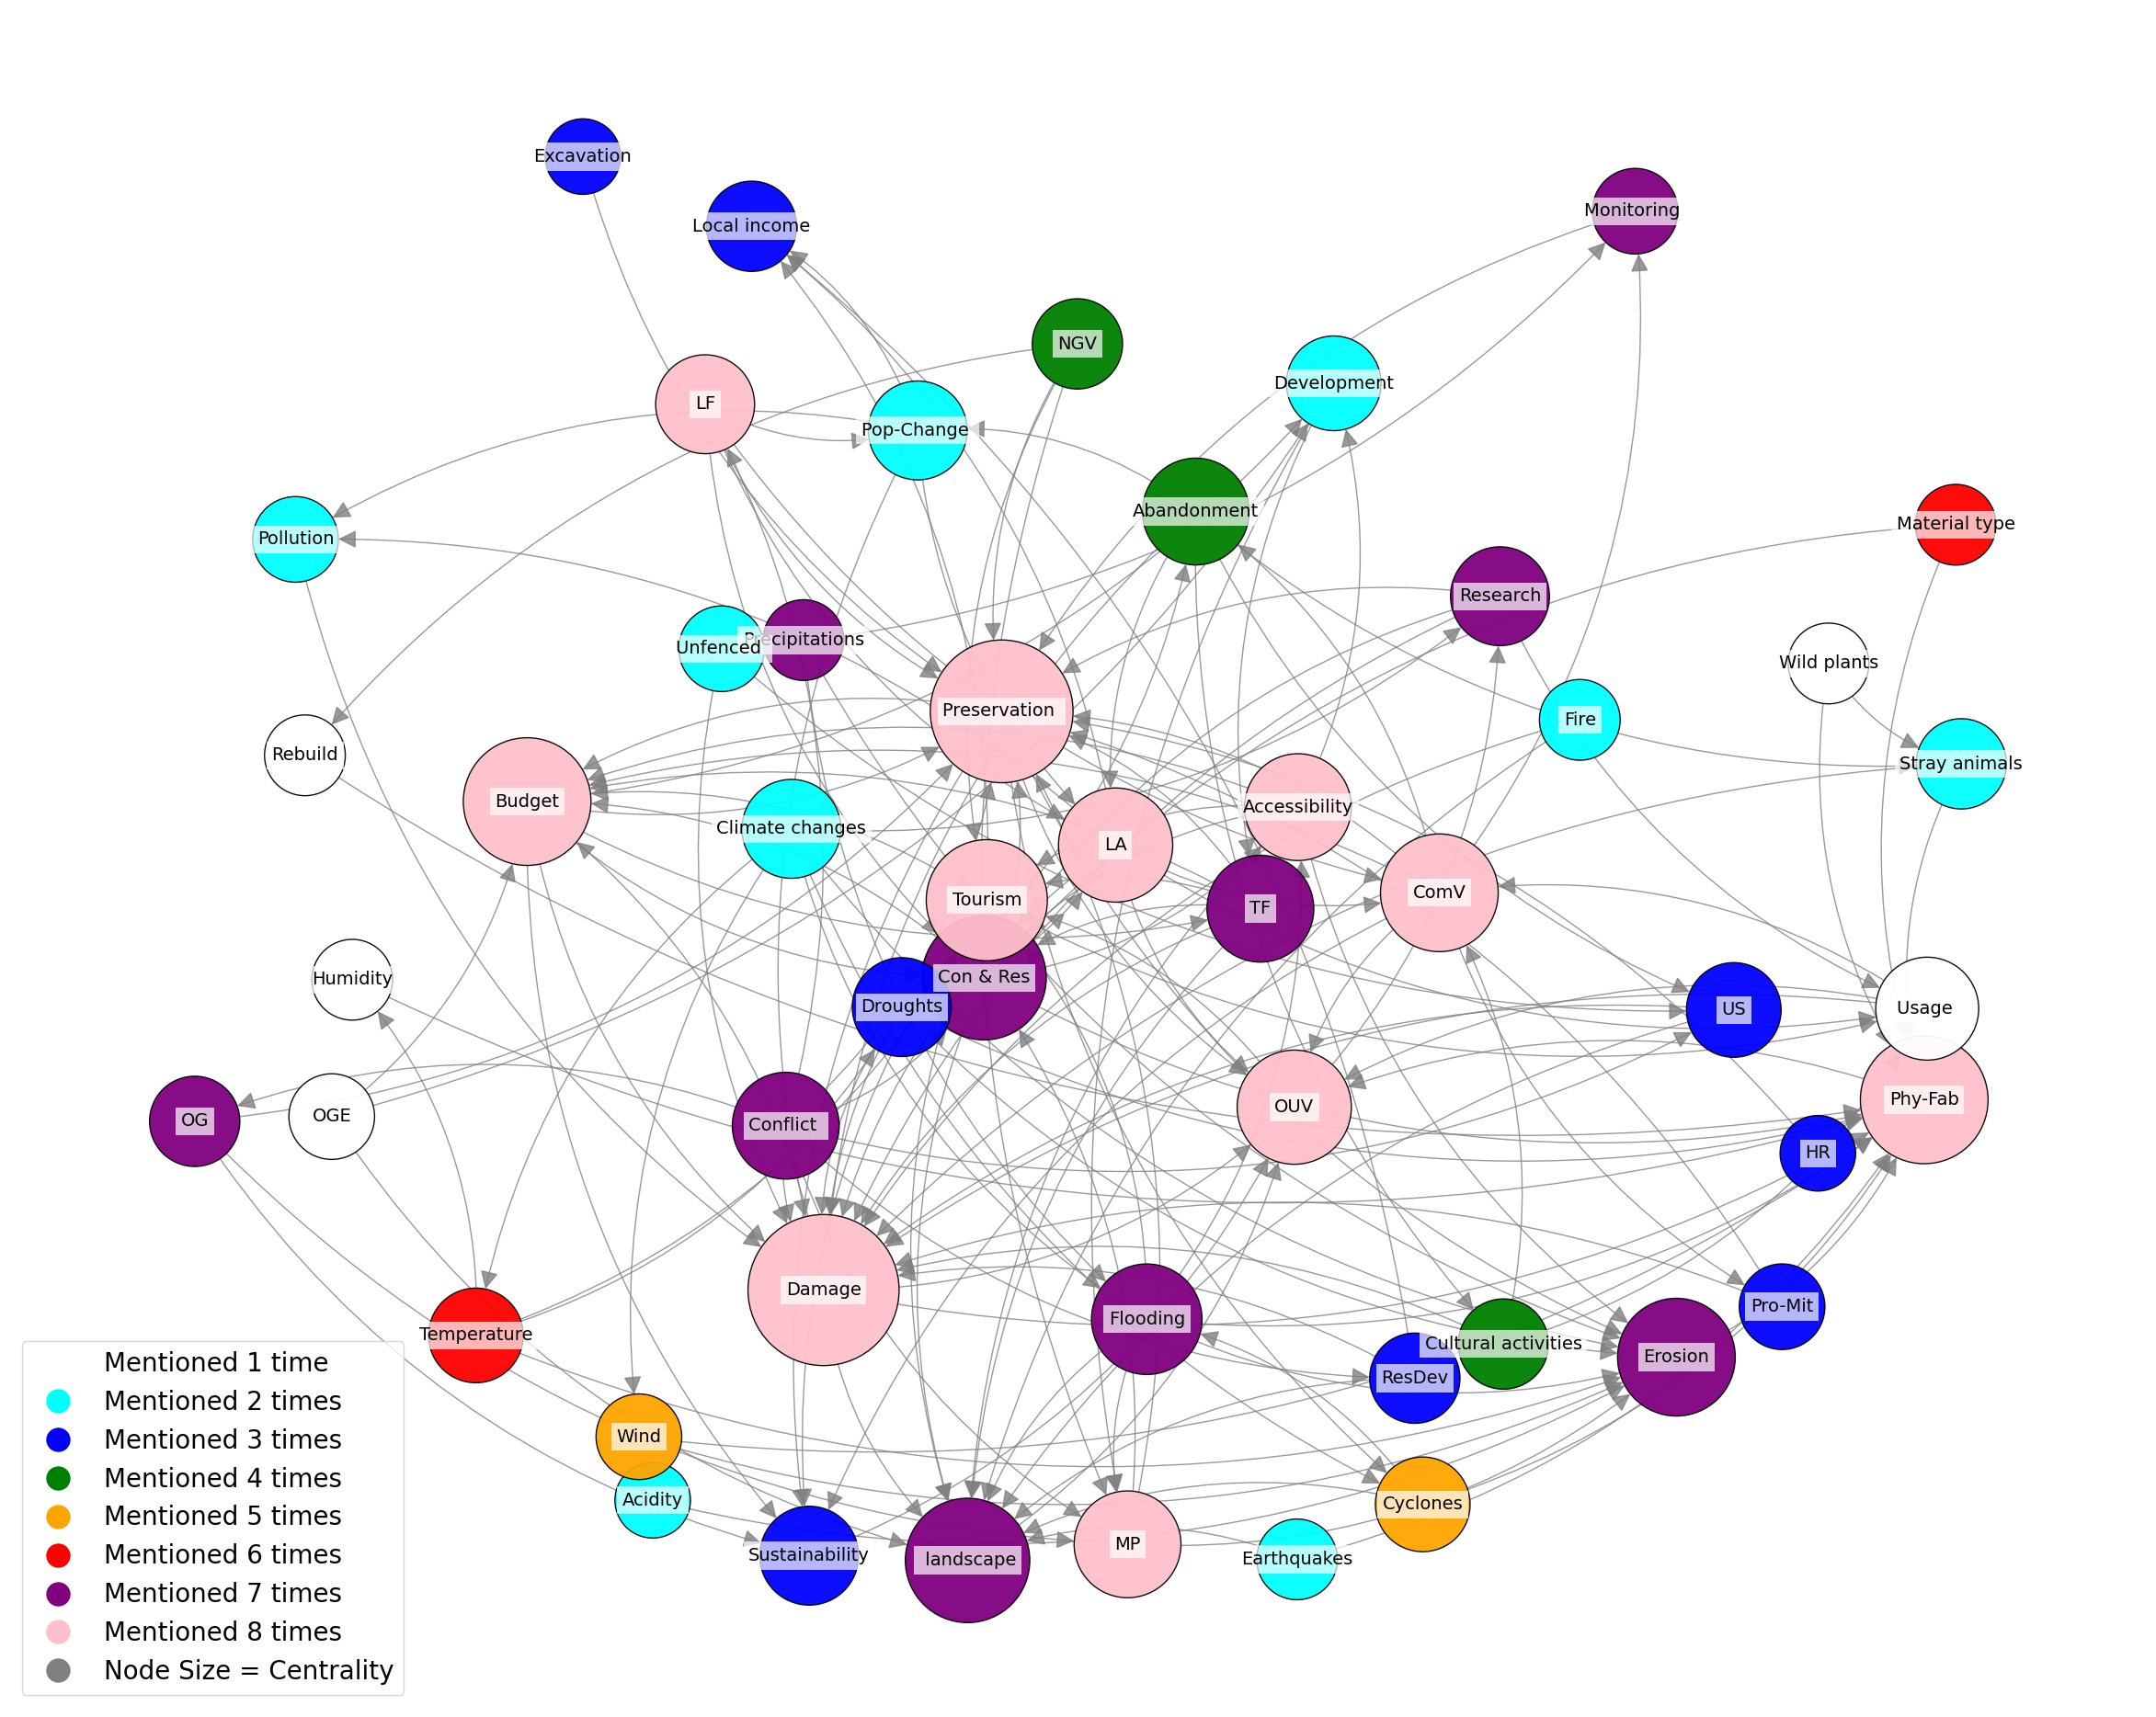

In [7]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from ast import literal_eval

# Read the concept frequency data
df_concept_frequency = pd.read_csv("Analysis and output folders/concept_frequency_across_fcms.csv")

# Read the concept ID to label mapping
concept_labels_df = pd.read_csv("Original Data/Concept labels.csv")
concept_labels = dict(zip(concept_labels_df['Concept ID'], concept_labels_df['Label']))

# Define the order of concepts
concept_order = [f"C{i}" for i in range(1, 51)]

# File paths for FCM CSV files
file_paths = [f'Original Data/EXPFCM{i}.csv' for i in range(1, 9)]

# Read each CSV file into a separate DataFrame
dfs = [pd.read_csv(file_path, index_col=0) for file_path in file_paths]

# Create a dictionary to store the color for each FCM
fcm_colors = {f'FCM{i+1}': color for i, color in enumerate(['pink', 'yellow', 'cyan', 'grey', 'blue', 'green', 'orange', 'purple'])}

# Create a dictionary to store the concept colors
concept_colors = {}

# Define colors for mentions
mention_colors = [
    'white',  # Mentioned 1 time
    'cyan',   # Mentioned 2 times
    'blue',   # Mentioned 3 times
    'green',  # Mentioned 4 times
    'orange', # Mentioned 5 times
    'red',    # Mentioned 6 times
    'purple', # Mentioned 7 times
    'pink'    # Mentioned 8 times
]

# Iterate over the concepts and assign colors based on the number of FCMs
for concept in df_concept_frequency['Concept']:
    count = sum(concept in df.columns for df in dfs)
    if 1 <= count <= 8:
        concept_colors[concept] = mention_colors[count - 1]  # Adjust index for colors
    else:
        concept_colors[concept] = 'gray'  # Default color if mentioned more than 8 times

# Create a directed graph
G = nx.DiGraph()

# Add nodes to the graph
G.add_nodes_from(concept_labels.keys())

# Add edges from the DataFrame (without frequency consideration)
frequency_df = pd.read_csv("Analysis and output folders/Relationship_frequency_across_fcms.csv")
frequency_df['Relationship'] = frequency_df['Relationship'].apply(literal_eval)

for index, row in frequency_df.iterrows():
    source, target = row['Relationship']
    G.add_edge(source, target)

# Set positions for the nodes using a layout algorithm with stronger repulsion
pos = nx.spring_layout(G, k=1.2, seed=42)  # Increased k for better separation

# Draw the graph with enhancements
plt.figure(figsize=(30, 24))  # Further increased figure size

# Draw nodes with larger size and better spacing
node_sizes = [3000 + 500 * G.degree(node) for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=[concept_colors.get(node, 'gray') for node in G.nodes()],
                       node_size=node_sizes, alpha=0.95, edgecolors='black')

# Draw edges without frequency information
nx.draw_networkx_edges(G, pos, alpha=0.8, edge_color='gray', arrows=True, arrowsize=30, connectionstyle='arc3,rad=0.2', node_size=node_sizes)

# Draw labels for nodes using the concept labels with larger font size
nx.draw_networkx_labels(G, pos, labels=concept_labels, font_size=14, font_family='sans-serif', 
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Show legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 1 time', markerfacecolor='white', markersize=20),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 2 times', markerfacecolor='cyan', markersize=20),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 3 times', markerfacecolor='blue', markersize=20),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 4 times', markerfacecolor='green', markersize=20),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 5 times', markerfacecolor='orange', markersize=20),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 6 times', markerfacecolor='red', markersize=20),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 7 times', markerfacecolor='purple', markersize=20),
    plt.Line2D([0], [0], marker='o', color='w', label='Mentioned 8 times', markerfacecolor='pink', markersize=20),
    plt.Line2D([0], [0], marker='o', color='w', label='Node Size = Centrality', markerfacecolor='gray', markersize=20),
]

plt.legend(handles=legend_elements, loc='lower left', title='', fontsize=20, title_fontsize=24)
plt.title("")
plt.axis('off')
plt.savefig("Analysis and output folders/improved_concept_centrality_fcm_graph_no_frequency.png", format='PNG', dpi=300, bbox_inches='tight')
plt.show()


### Enhancing the visualization of the final result

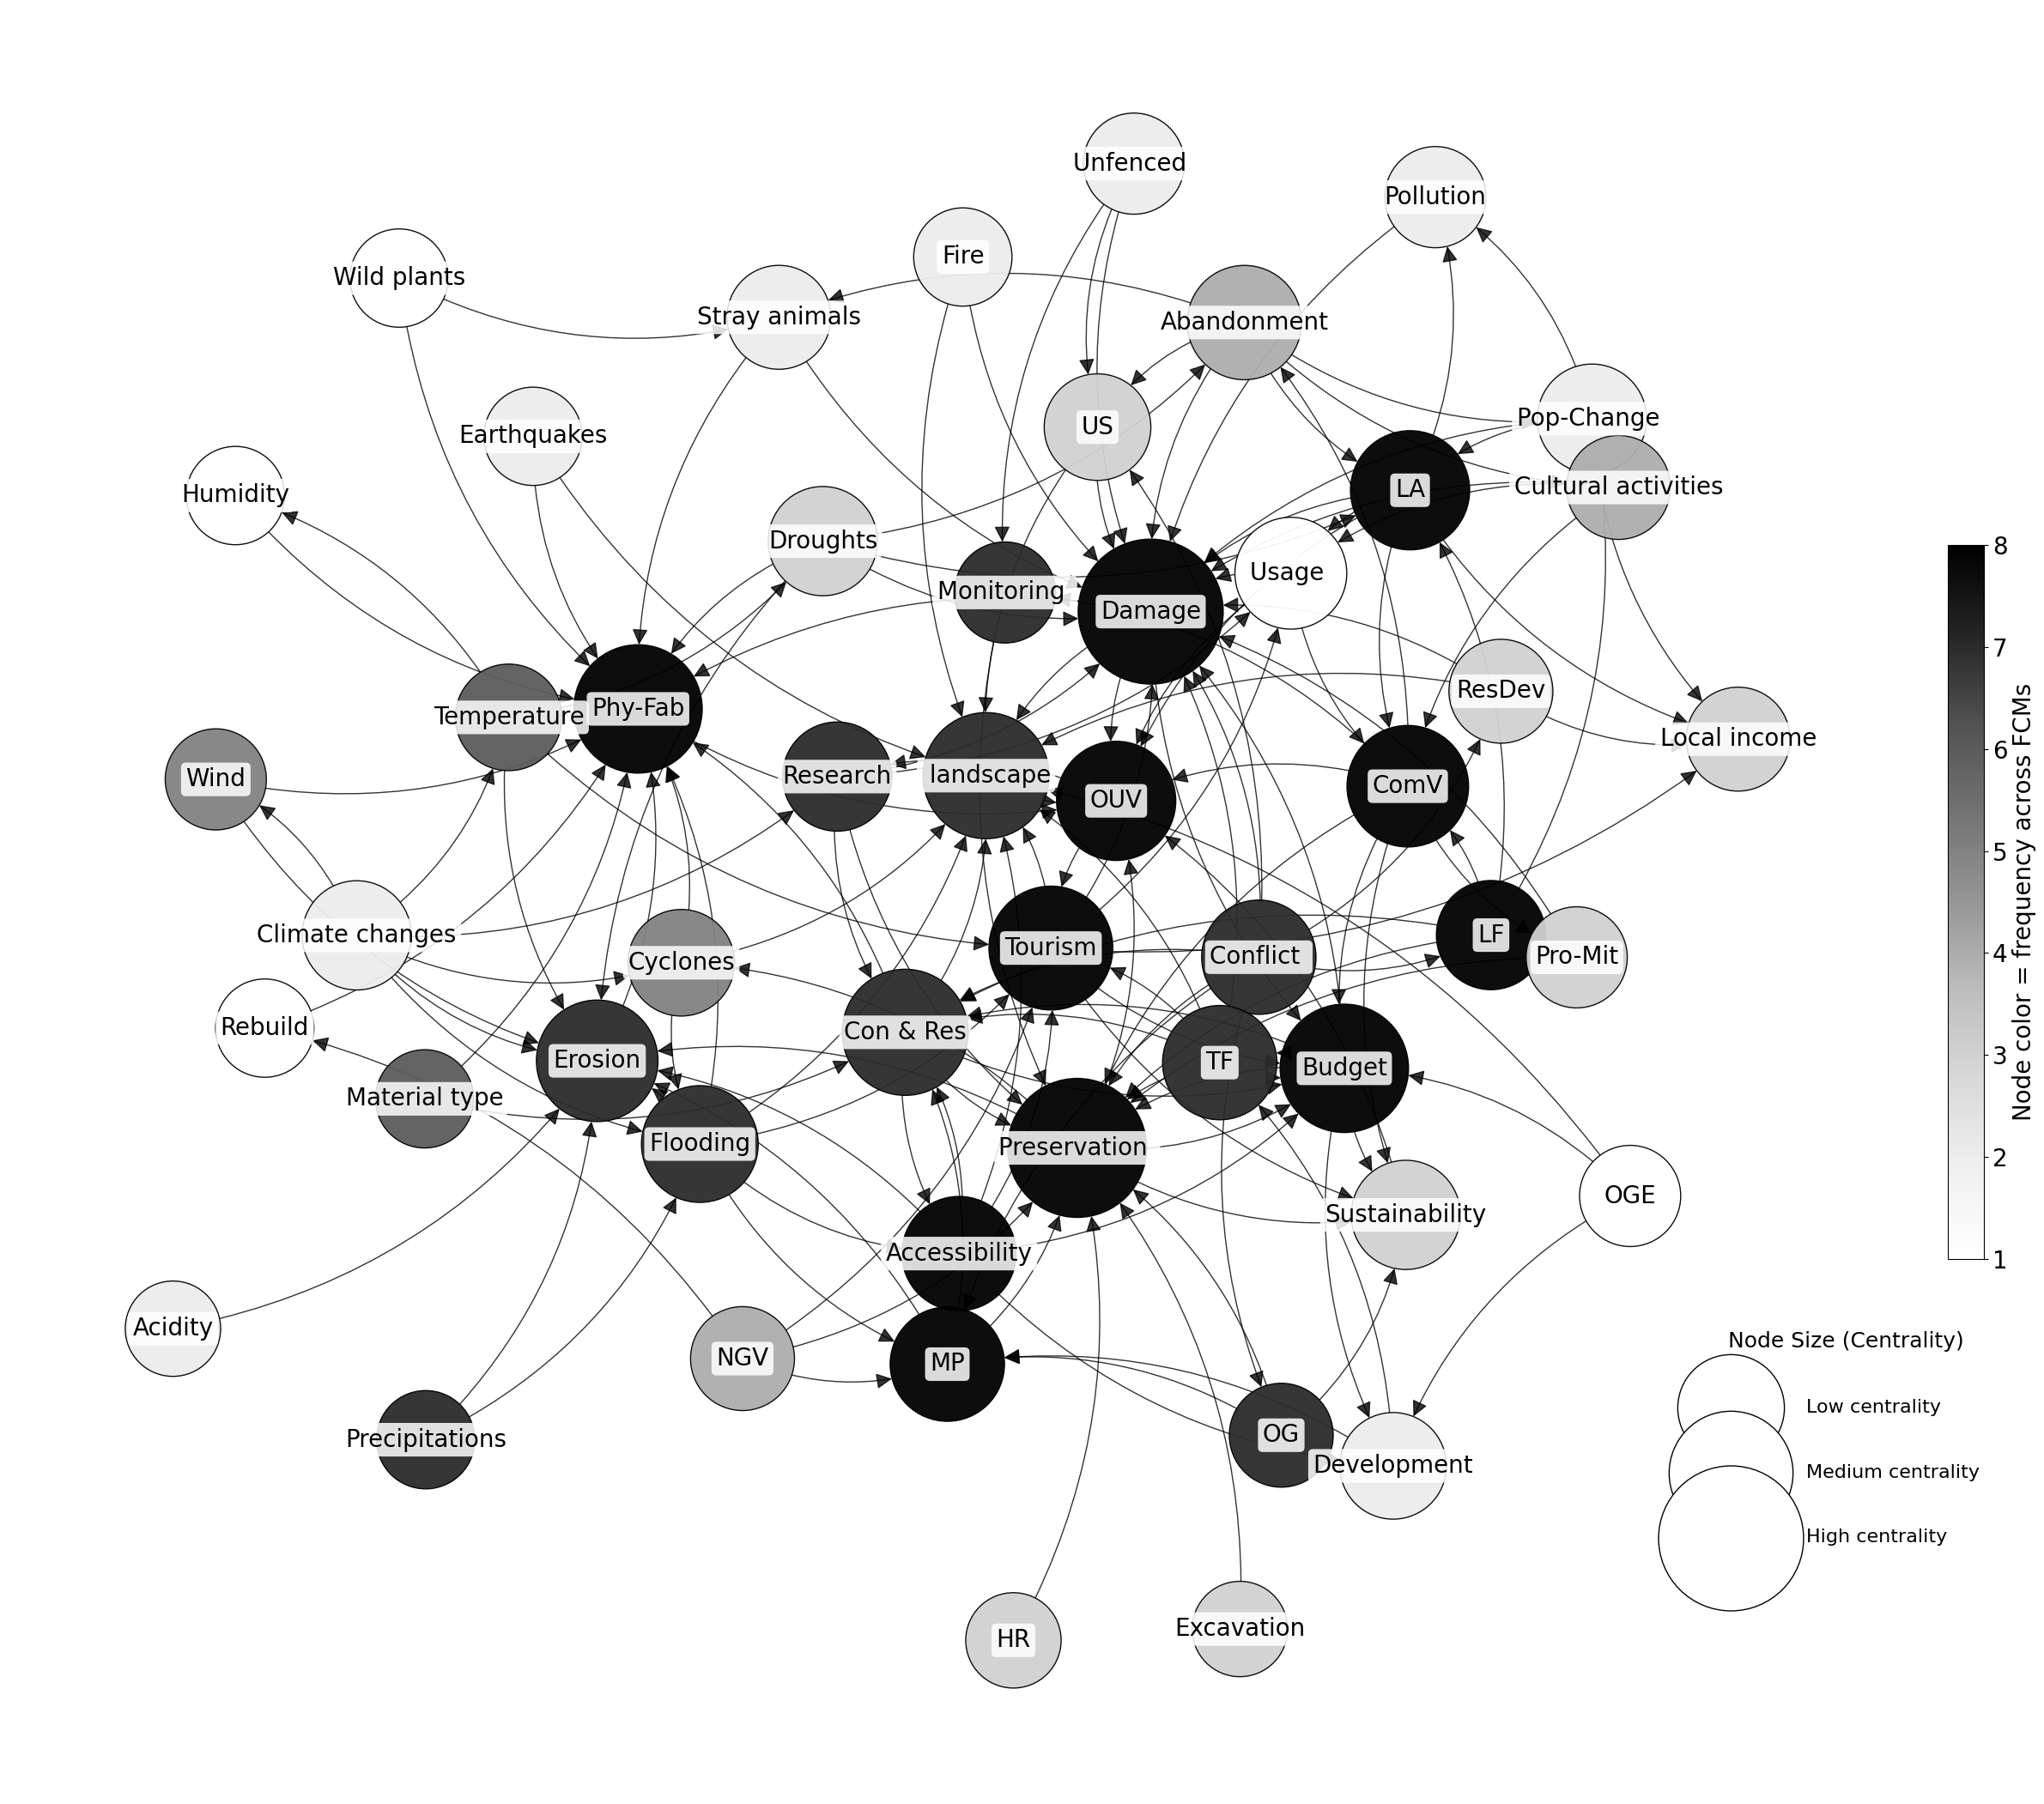

In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from ast import literal_eval
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --- Load data ---
df_concept_frequency = pd.read_csv(
    "Analysis and output folders/concept_frequency_across_fcms.csv"
)

concept_labels_df = pd.read_csv("Original Data/Concept labels.csv")
concept_labels = dict(
    zip(concept_labels_df['Concept ID'], concept_labels_df['Label'])
)

file_paths = [f'Original Data/EXPFCM{i}.csv' for i in range(1, 9)]
dfs = [pd.read_csv(file_path, index_col=0) for file_path in file_paths]

# --- Frequency calculation ---
concept_frequency = {
    concept: sum(concept in df.columns for df in dfs)
    for concept in df_concept_frequency['Concept']
}

# --- Color mapping (GREYSCALE) ---
max_freq = max(concept_frequency.values())
min_freq = min(concept_frequency.values())
norm = mcolors.Normalize(vmin=min_freq, vmax=max_freq)

colormap = cm.get_cmap('Greys')  # <-- GREY SHADES
concept_colors = {
    concept: mcolors.to_hex(colormap(norm(freq)))
    for concept, freq in concept_frequency.items()
}

# --- Graph construction ---
G = nx.DiGraph()
G.add_nodes_from(concept_labels.keys())

frequency_df = pd.read_csv(
    "Analysis and output folders/Relationship_frequency_across_fcms.csv"
)
frequency_df['Relationship'] = frequency_df['Relationship'].apply(literal_eval)

for _, row in frequency_df.iterrows():
    source, target = row['Relationship']
    G.add_edge(source, target)

# --- Centrality ---
centrality_dict = dict(G.degree())
node_sizes = [6000 + 400 * centrality_dict[node] for node in G.nodes()]

# --- Layout using Graphviz ---
pos = nx.nx_agraph.graphviz_layout(G, prog='neato')

# --- Main figure ---
fig, ax = plt.subplots(figsize=(28, 22))

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax,
    node_color=[concept_colors.get(node, '#cfcfcf') for node in G.nodes()],
    node_size=node_sizes,
    edgecolors='black',
    alpha=0.95
)

# Draw edges
nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    edge_color='black',
    alpha=0.8,
    arrows=True,
    arrowsize=28,
    connectionstyle='arc3,rad=0.2',
    node_size=node_sizes
)

# Draw labels (high contrast, readable)
nx.draw_networkx_labels(
    G,
    pos,
    labels=concept_labels,
    ax=ax,
    font_size=20,
    font_family='sans-serif',
    bbox=dict(
        facecolor='white',
        alpha=0.85,
        edgecolor='none',
        boxstyle='round,pad=0.2'
    )
)

# --- Colorbar (node frequency) ---
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label('Node color = frequency across FCMs', size=20)
cbar.ax.tick_params(labelsize=20)

# --- Centrality legend (FLOATING, NO BOX) ---
legend_labels = ['Low centrality', 'Medium centrality', 'High centrality']
legend_centralities = [5, 12, 22]
legend_sizes = [6000 + 400 * c for c in legend_centralities]

size_handles = [
    plt.scatter([], [], s=size, c='white', edgecolors='black', label=label)
    for size, label in zip(legend_sizes, legend_labels)
]

plt.legend(
    handles=size_handles,
    title="Node Size (Centrality)",
    loc='lower right',
    bbox_to_anchor=(1.05, 0.13),
    fontsize=16,
    title_fontsize=18,
    scatterpoints=1,
    labelspacing=2.5,
    handletextpad=3,
    frameon=False   # <-- NO LEGEND BOX
)

# --- Save centrality table ---
centrality_df = pd.DataFrame({
    'Concept ID': list(centrality_dict.keys()),
    'Label': [concept_labels.get(c, '') for c in centrality_dict.keys()],
    'Degree Centrality': list(centrality_dict.values()),
    'Frequency (No. of FCMs)': [
        concept_frequency.get(c, 0) for c in centrality_dict.keys()
    ]
}).sort_values(by='Degree Centrality', ascending=False)

centrality_df.to_csv(
    "Analysis and output folders/concept_centrality_and_frequency.csv",
    index=False
)

# --- Finalize and save figure ---
ax.axis('off')
plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.98])

plt.savefig(
    "Analysis and output folders/FINAL_graph_GRAPHVIZ_LAYOUT_with_legend.pdf",
    format="PDF",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()



### the final result represent: 
Concepts Frequency and centrality across eight FCMs .Node color indicates how often each concept appears across all FCMs (from light = low frequency to dark = high frequency). Node size reflects centrality, representing concept importance. Arrows show the direction of causal influence between concepts.